Resonance frequency = 1.12 Hz


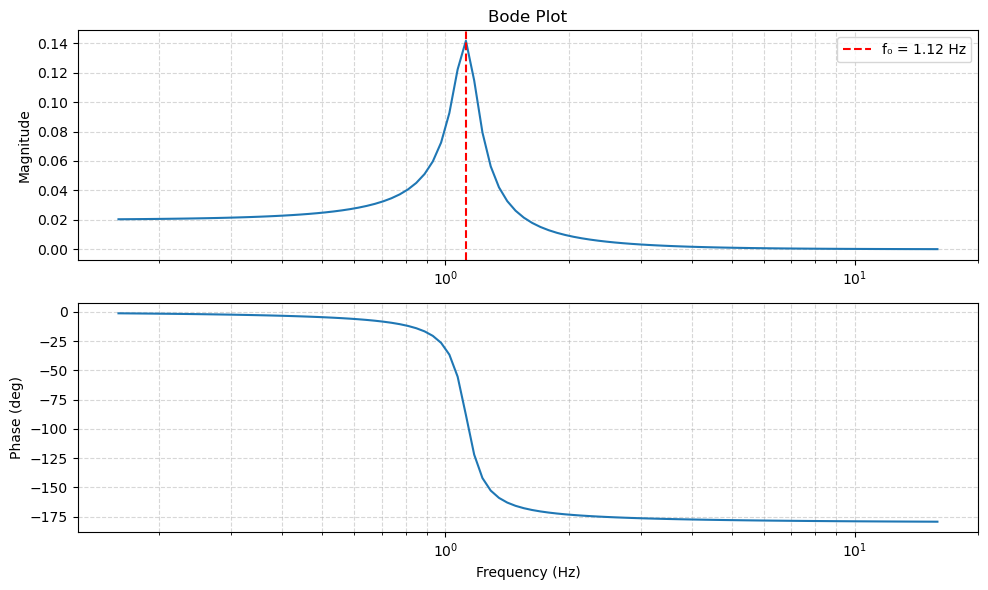

In [54]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import ss2tf, TransferFunction, bode, step

"""
State-Space Model of a Damped Harmonic Oscillator
=====================================================

m x'' + b x' + kx = F(t)

State-space form:
    x' = A x + B u
    y  = C x + D u

Transfer function:
    H(s) = C (sI - A)^(-1) B + D
"""

# Parameters
m = 1.0
k = 50.0
b = 1.0

# State-space matrices
A = np.array([[0, 1], [-k/m, -b/m]])

B = np.array([[0], [1/m]])

C = np.array([[1, 0]])  

D = np.array([[0]])

# Convert to transfer function
num, den = ss2tf(A, B, C, D)
system = TransferFunction(num[0], den)

# Bode plot
w, mag, phase = bode(system)

# Convert rad/s to Hz
f = w / (2*np.pi)

# Resonance frequency from eigenvalues
eigenvalues = np.linalg.eigvals(A)
omega0 = np.abs(np.imag(eigenvalues[0]))
f0 = omega0 / (2*np.pi)

print(f"Resonance frequency = {f0:.2f} Hz")

# Plot
plt.figure(figsize=(10,6))

#Magnitude Plot
plt.subplot(2,1,1)
plt.semilogx(f, 10**(mag/20))
plt.axvline(f0, color='red', linestyle='--', label=f"f₀ = {f0:.2f} Hz")
plt.ylabel("Magnitude")
plt.title("Bode Plot")
plt.grid(which='both', linestyle='--', alpha=0.5)
plt.legend()

#Phase Plot
plt.subplot(2,1,2)
plt.semilogx(f, phase)
plt.xlabel("Frequency (Hz)")
plt.ylabel("Phase (deg)")
plt.grid(which='both', linestyle='--', alpha=0.5)
plt.tight_layout()

plt.show()

<h2>MODELING OF SINGE STAGE SUSPENSION MODES</h2>
<hr>

The transfer functions for the single-stage suspension using 4 wires are obtained using state-space modeling. The suspension modes considered are in the following order:

1. Vertical Mode  
2. Longitudinal & Pitch Mode  
3. Transverse & Roll Mode  
4. Yaw Mode

The transfer functions and Bode plots are generated using the corresponding state-space matrices. The resonance frequencies of the suspension modes are calculated using the eigenvalues of the system matrix A and verified using the resonance peaks observed in the transfer function magnitude plots.

Vertical mode frequency = 52.26 Hz
Resonance frequency from eigenvalues = 52.26 Hz


C:\Users\shrey\anaconda3\Lib\site-packages\scipy\signal\_filter_design.py:1109: BadCoefficients: Badly conditioned filter coefficients (numerator): the results may be meaningless
  b, a = normalize(b, a)


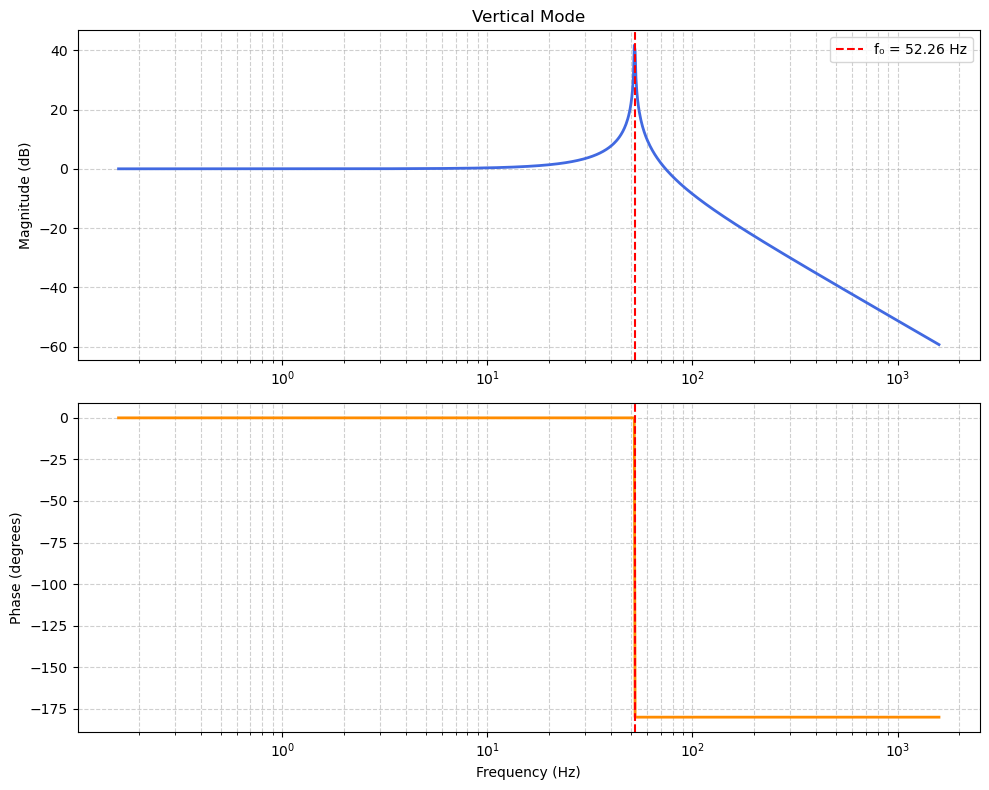

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import StateSpace,bode

"""
Vertical Motion
===============

Equation of motion:

m z'' = -4k(z-z0)

where,

k = EA/l

m       : Mass of the suspended object (kg)
l       : Length of the suspension wire (m)
E       : Young's modulus of the wire material (Pa)
A       : Cross-sectional area of the wire (m²)
R       : Radius of the suspension wire (m)
k       : Axial stiffness of one suspension wire (N/m)
z       : Vertical displacement of the mass (m)
z0      : Equilibrium position of the mass (m)
"""

#Physical parameters
g = 9.81                 #Acceleration due to gravity [m/s^2]
l = 0.6                  #Wire length [m]
m = 0.102                #Mass [kg]
I_x = 37.5e-6            #Roll moment of inertia
I_z = 22.7e-06           #Yaw moment of inertia
I_y = 22e-06             #Pitch moment of inertia [kg.m^2]
w = 0.007/2              #Offset in X direction [m]
t = 0.0508/2             #Offset in Y direction [m]
d = 0.0508               #Offset in Z direction [m]
R = 0.5e-04              #Wire diameter [m]
E = 2.1e11               #Young's modulus of steel

A_wire = np.pi*R**2

#Axial wire stiffness
k = E*A_wire / l

# Vertical mode frequency
omega_vert = np.sqrt(4*k/m)
f_vert = omega_vert/(2*np.pi)

print(f"Vertical mode frequency = {f_vert:.2f} Hz")

# State-space matrices
A = np.array([[0,1],
              [-4*k/m,0]])

B = np.array([[0],
              [4*k/m]])

C = np.array([[1,0]])

D = np.array([[0]])

# Create system
system = StateSpace(A,B,C,D)

# Resonance frequency from eigenvalues
eigenvalues = np.linalg.eigvals(A)
omega = np.abs(np.imag(eigenvalues[0]))
f_res = omega/(2*np.pi)

print(f"Resonance frequency from eigenvalues = {f_res:.2f} Hz")

# Frequency range
w_freq = np.logspace(0,4,1000)

# Bode response
w_freq,mag,phase = bode(system,w_freq)

# Convert rad/s to Hz
f = w_freq/(2*np.pi)

# Plot
plt.figure(figsize=(10,8))
plt.subplot(2,1,1)
plt.semilogx(f,mag,color='royalblue',linewidth=2)
plt.axvline(f_res,color='red',linestyle='--',label=f"f₀ = {f_res:.2f} Hz")
plt.title("Vertical Mode")
plt.ylabel("Magnitude (dB)")
plt.grid(which='both',linestyle='--',alpha=0.6)
plt.legend()
plt.subplot(2,1,2)
plt.semilogx(f,phase,color='darkorange',linewidth=2)
plt.axvline(f_res,color='red',linestyle='--')
plt.xlabel("Frequency (Hz)")
plt.ylabel("Phase (degrees)")
plt.grid(which='both',linestyle='--',alpha=0.6)
plt.tight_layout()
plt.show()

Longitudinal and Pitch Frequencies (Hz):
14.78 Hz
14.78 Hz
0.64 Hz
0.64 Hz


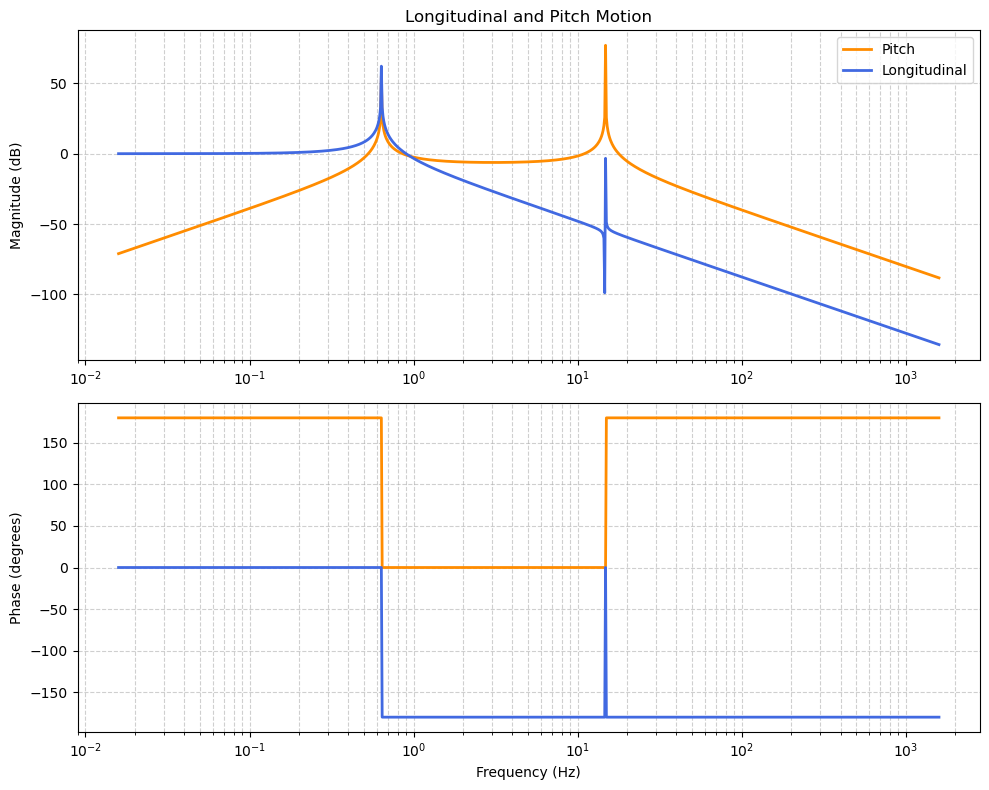

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import StateSpace,bode
from scipy.linalg import eig

"""
Longitudinal and Pitch Motion
=============================

Equation of motion:

I phi'' = (-mgd - (mgd²/l) - 4kw²)phi - (mgd/l)(x_n - x_0)

m x_n'' = -mg(x_n - x_0)/l - (mgd/l)phi

where,

m    : Mass of the suspended object (kg)
g    : Gravitational acceleration (m/s²)
l    : Length of the suspension wire (m)
k    : Effective stiffness of the suspension wire (N/m)
w    : Horizontal distance between the center of mass and the wire attachment point in the x-direction (m)
d    : Vertical distance between the center of mass and the wire attachment point in the z-direction (m)
I    : Moment of inertia (kg m²)
phi  : Pitch angle
x_n  : Longitudinal displacement of the center of mass
x_0  : Suspension point displacement
"""
#Physical parameters
g = 9.81                 #Acceleration due to gravity [m/s^2]
l = 0.6                  #Wire length [m]
m = 0.102                #Mass [kg]
I_x = 37.5e-6            #Roll moment of inertia
I_z = 22.7e-06           #Yaw moment of inertia
I_y = 22e-06             #Pitch moment of inertia [kg.m^2]
w = 0.007/2              #Offset in X direction [m]
t = 0.0508/2             #Offset in Y direction [m]
d = 0.0508               #Offset in Z direction [m]
R = 0.5e-04              #Wire diameter [m]
E = 2.1e11               #Young's modulus of steel

A_wire = np.pi*R**2

#Axial wire stiffness
k = E*A_wire / l

# Coefficients
k11 = (1/I_y)*(-m*g*d - (m*g*d**2)/l - 4*k*w**2)
k21 = -g*d/l
k12 = -m*g*d/(I_y*l)
k22 = -g/l

# State-space matrices
A = np.array([[0,0,1,0],
              [0,0,0,1],
              [k11,k12,0,0],
              [k21,k22,0,0]])

B = np.array([[0],
              [0],
              [m*g*d/(I_y*l)],
              [g/l]])

C_phi = np.array([[1,0,0,0]])

C_xn = np.array([[0,1,0,0]])

D = np.array([[0]])

# Create systems
system_phi = StateSpace(A,B,C_phi,D)
system_xn = StateSpace(A,B,C_xn,D)

# Resonance frequencies from eigenvalues
eigenvalues,_ = eig(A)
frequencies = np.abs(eigenvalues)/(2*np.pi)

print("Longitudinal and Pitch Frequencies (Hz):")

for f0 in frequencies:
    if f0 > 0:
        print(f"{f0:.2f} Hz")

# Frequency range
w_freq = np.logspace(-1,4,1000)

# Bode response
w_freq,mag_phi,phase_phi = bode(system_phi,w_freq)
_,mag_xn,phase_xn = bode(system_xn,w_freq)

# Convert rad/s to Hz
f = w_freq/(2*np.pi)

# Plot
plt.figure(figsize=(10,8))
plt.subplot(2,1,1)
plt.semilogx(f,mag_phi,color='darkorange',linewidth=2,label='Pitch')
plt.semilogx(f,mag_xn,color='royalblue',linewidth=2,label='Longitudinal')
plt.title("Longitudinal and Pitch Motion")
plt.ylabel("Magnitude (dB)")
plt.grid(which='both',linestyle='--',alpha=0.6)
plt.legend()
plt.subplot(2,1,2)
plt.semilogx(f,phase_phi,color='darkorange',linewidth=2)
plt.semilogx(f,phase_xn,color='royalblue',linewidth=2)
plt.xlabel("Frequency (Hz)")
plt.ylabel("Phase (degrees)")
plt.grid(which='both',linestyle='--',alpha=0.6)
plt.tight_layout()
plt.show()

Transverse and Roll Frequencies (Hz):
69.49 Hz
69.49 Hz
0.64 Hz
0.64 Hz


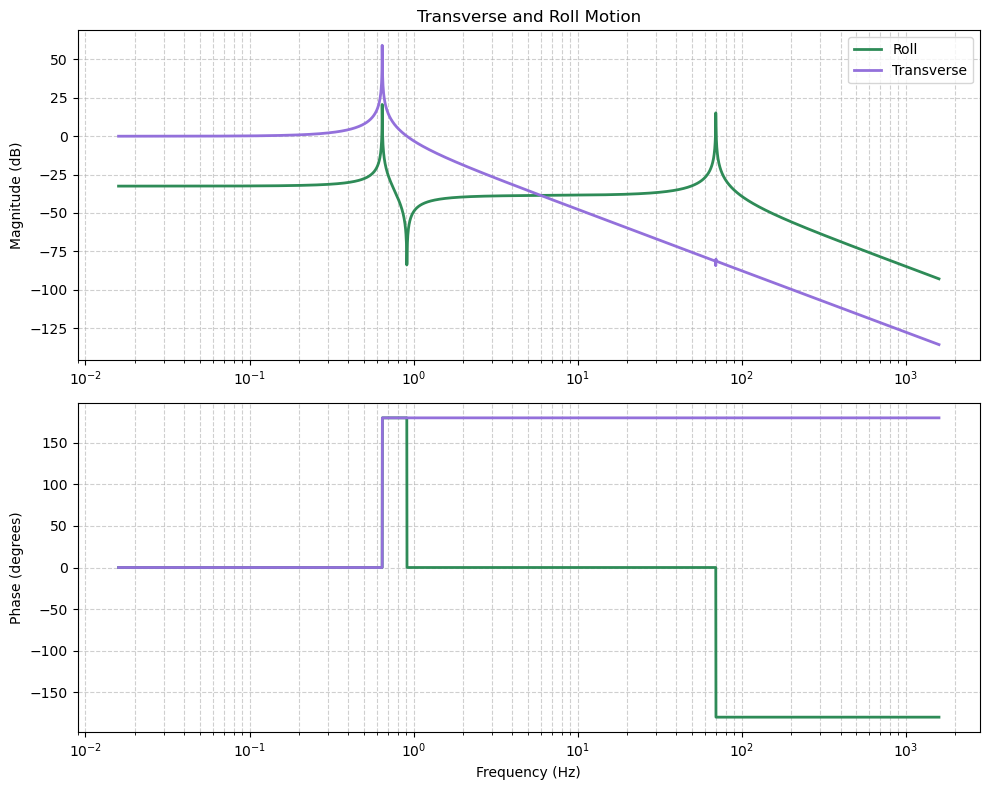

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import StateSpace,bode
from scipy.linalg import eig

"""
Transverse and Roll Motion
===========================

Equation of motion:

m y_n'' = -mg(y_n-y_0)/l - (mgd/l)psi

I psi'' = (-mgd - (mgd²/l) - 2kt²)psi + (mgd/l)(y_n-y_0)

where,

m      : Mass of the suspended object (kg)
g      : Gravitational acceleration (m/s²)
l      : Length of the suspension wire (m)
k      : Effective restoring stiffness (N/m)
t      : Horizontal distance between COM and wire attachment point in y-direction (m)
d      : Vertical COM offset in z direction (m)
I      : Moment of inertia for roll motion (kg m²)
psi    : Roll angle
y_n    : Transverse displacement
y_0    : Suspension point displacement
"""

#Physical parameters
g = 9.81                 #Acceleration due to gravity [m/s^2]
l = 0.6                  #Wire length [m]
m = 0.102                #Mass [kg]
I_x = 37.5e-6            #Roll moment of inertia
I_z = 22.7e-06           #Yaw moment of inertia
I_y = 22e-06             #Pitch moment of inertia [kg.m^2]
w = 0.007/2              #Offset in X direction [m]
t = 0.0508/2             #Offset in Y direction [m]
d = 0.0508               #Offset in Z direction [m]
R = 0.5e-04              #Wire diameter [m]
E = 2.1e11               #Young's modulus of steel

A_wire = np.pi*R**2

#Axial wire stiffness
k = E*A_wire / l

# Coefficients
j11 = (1/I_x)*(-m*g*d - (m*g*d**2)/l - 4*k*t**2)
j12 = m*g*d/(I_x*l)
j21 = -g*d/l
j22 = -g/l

# State-space matrices
A = np.array([[0,0,1,0],
              [0,0,0,1],
              [j11,j12,0,0],
              [j21,j22,0,0]])

B = np.array([[0],
              [0],
              [m*g*d/(I_x*l)],
              [g/l]])

C_psi = np.array([[1,0,0,0]])

C_yn = np.array([[0,1,0,0]])

D = np.array([[0]])

# Create systems
system_psi = StateSpace(A,B,C_psi,D)
system_yn = StateSpace(A,B,C_yn,D)

# Resonance frequencies from eigenvalues
eigenvalues,_ = eig(A)
frequencies = np.abs(eigenvalues)/(2*np.pi)

print("Transverse and Roll Frequencies (Hz):")

for f0 in frequencies:
    if f0 > 0:
        print(f"{f0:.2f} Hz")

# Frequency range
w_freq = np.logspace(-1,4,4000)

# Bode response
w_freq,mag_psi,phase_psi = bode(system_psi,w_freq)
_,mag_yn,phase_yn = bode(system_yn,w_freq)

# Convert rad/s to Hz
f = w_freq/(2*np.pi)

# Plot
plt.figure(figsize=(10,8))
plt.subplot(2,1,1)
plt.semilogx(f,mag_psi,color='seagreen',linewidth=2,label='Roll')
plt.semilogx(f,mag_yn,color='mediumpurple',linewidth=2,label='Transverse')
plt.title("Transverse and Roll Motion")
plt.ylabel("Magnitude (dB)")
plt.grid(which='both',linestyle='--',alpha=0.6)
plt.legend()
plt.subplot(2,1,2)
plt.semilogx(f,phase_psi,color='seagreen',linewidth=2)
plt.semilogx(f,phase_yn,color='mediumpurple',linewidth=2)
plt.xlabel("Frequency (Hz)")
plt.ylabel("Phase (degrees)")
plt.grid(which='both',linestyle='--',alpha=0.6)
plt.tight_layout()
plt.show()

Yaw Frequencies (Hz):
1.11 Hz
1.11 Hz


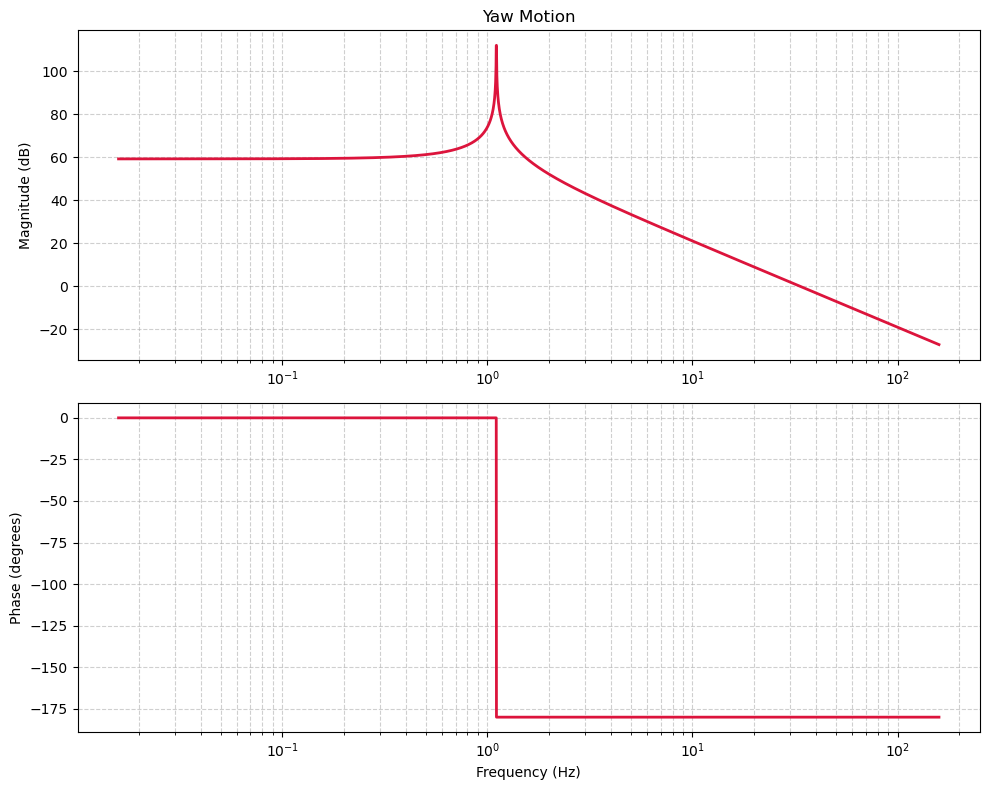

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import StateSpace,bode
from scipy.linalg import eig

"""
Yaw Motion
==========

Equation of motion:

I sigma'' = -((t²+w²)mg/l)sigma + tau

where,

m      : Mass of the suspended object (kg)
g      : Gravitational acceleration (m/s²)
l      : Length of the suspension wire (m)
t      : y-direction distance between COM and wire attachment point (m)
w      : x-direction distance between COM and wire attachment point (m)
I      : Moment of inertia for yaw motion (kg m²)
sigma  : Yaw angle
tau    : External yaw torque
"""
#Physical parameters
g = 9.81                 #Acceleration due to gravity [m/s^2]
l = 0.6                  #Wire length [m]
m = 0.102                #Mass [kg]
I_x = 37.5e-6            #Roll moment of inertia
I_z = 22.7e-06           #Yaw moment of inertia
I_y = 22e-06             #Pitch moment of inertia [kg.m^2]
w = 0.007/2              #Offset in X direction [m]
t = 0.0508/2             #Offset in Y direction [m]
d = 0.0508               #Offset in Z direction [m]
R = 0.5e-04              #Wire diameter [m]
E = 2.1e11               #Young's modulus of steel

A_wire = np.pi*R**2

#Axial wire stiffness
k = E*A_wire / l

# State-space matrices
A = np.array([[0, 1],
              [-((t**2 + w**2) * m * g) / (I_z * l), 0]])

B = np.array([[0],
              [1 / I_z]])

C = np.array([[1, 0]])

D = np.array([[0]])

# Create system
system = StateSpace(A,B,C,D)

# Resonance frequencies from eigenvalues
eigenvalues,_ = eig(A)
frequencies = np.abs(eigenvalues)/(2*np.pi)

print("Yaw Frequencies (Hz):")

for f0 in frequencies:
    if f0 > 0:
        print(f"{f0:.2f} Hz")

# Frequency range
w_freq = np.logspace(-1,3,4000)

# Bode response
w_freq,mag,phase = bode(system,w_freq)

# Convert rad/s to Hz
f = w_freq/(2*np.pi)

# Plot
plt.figure(figsize=(10,8))
plt.subplot(2,1,1)
plt.semilogx(f,mag,color='crimson',linewidth=2)
plt.title("Yaw Motion")
plt.ylabel("Magnitude (dB)")
plt.grid(which='both',linestyle='--',alpha=0.6)
plt.subplot(2,1,2)
plt.semilogx(f,phase,color='crimson',linewidth=2)
plt.xlabel("Frequency (Hz)")
plt.ylabel("Phase (degrees)")
plt.grid(which='both',linestyle='--',alpha=0.6)
plt.tight_layout()
plt.show()